### Libraries

In [35]:
import os
import subprocess
import brainspace.mesh as mesh
import nibabel as nib
import numpy as np
import pandas as pd
from lapy import shapedna, TriaMesh
from brainspace.plotting.surface_plotting import plot_hemispheres
from brainspace.mesh.mesh_io import read_surface
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

### Load surfaces and masks

In [3]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
#inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
#inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nib.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nib.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)
np.savetxt('/host/verges/tank/data/youngeun/eigenmode/fsLR-5k.L.medialwall.txt', mask_lh, delimiter=',')
np.savetxt('/host/verges/tank/data/youngeun/eigenmode/fsLR-5k.R.medialwall.txt', mask_rh, delimiter=',')

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')

# Boolean mask
mask_surf = mask_5k != 0

### Functions

In [4]:
# helper functions
def laplace_beltrami(tria, n_modes):
    """Calculate the eigenvalues and eigenmodes of a surface.

    Parameters
    ----------
    tria (vtk object): surface triangular mesh
    n_modes (int): number of eigenmodes to be calculated

    Returns
    ------
    evals (array): eigenvalues
    emodes (array): eigenmodes
    """

    # laplace-beltrami operator
    lbo = shapedna.compute_shapedna(tria, k=n_modes)
    evals, emodes = lbo["Eigenvalues"], lbo["Eigenvectors"]

    # Normalize and reweight eigenvalues
    evals = shapedna.normalize_ev(tria, evals, method="geometry")
    evals = shapedna.reweight_ev(evals)

    return evals, emodes


def indices(surface_old, surface_new):
    """Extract indices of vertices of the two surfaces that match.

    Parameters
    ----------
    surface_old (vtk object): surface triangular mesh
    surface_new (vtk ibject): surface triangular mesh

    Returns
    ------
    indices (array): indices of vertices
    """

    # match vertices between old/new surface
    idx = np.zeros([np.shape(surface_new.Points)[0], 1])
    for i in range(np.shape(surface_new.Points)[0]):
        idx[i] = np.where(
            np.all(np.equal(surface_new.Points[i, :], surface_old.Points), axis=1)
        )[0][0]
    idx = idx.astype(int)

    return idx


def surface_eigenmodes(surface_fname, medial_fname, n_modes=200):
    """Calculate the eigenmodes of a cortical surface with application of a mask (e.g., to remove the medial wall).

    Parameters
    ----------
    surface_fname (str): Filename of input fsnative surface
    medial_fname (str): Filename of mask to be applied on the surface (e.g., cortex without medial wall, values = 1 for mask and 0 elsewhere)
    n_modes (int): Number of eigenmodes to be calculated

    Returns
    ------
    evals (array): eigenvalues
    emodes (array): eigenmodes
    """

    # load fsnative surface
    surface = mesh.mesh_io.read_surface(surface_fname)

    # mask medial wall
    medial = np.loadtxt(medial_fname)
    #cortex = nib.freesurfer.io.read_label(medial_fname)
    #medial = np.zeros(len(surface.Points))
    #medial[cortex] = 1    
    new_surface = mesh.mesh_operations.mask_points(surface, medial)

    # calculate eigenvalues and eigenmodes
    vtk_fname = (
        f"{work_dir}/tmp/{os.path.basename(surface_fname).replace('.surf.gii', '.vtk')}"
    )
    if not os.path.isfile(vtk_fname):
        vtk_fname = (
            f"{work_dir}/tmp/{os.path.basename(surface_fname).replace('.surf.gii', '.vtk')}"
        )        
        cmd = f"source /data/mica1/01_programs/micapipe-v0.2.0/functions/init.sh; mris_convert {surface_fname} {vtk_fname}"
        process = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        
    tria = TriaMesh.read_vtk(vtk_fname)
    tria.v = new_surface.Points
    tria.t = np.reshape(new_surface.Polygons, [new_surface.n_cells, 4])[:, 1:4]
    evals, emodes = laplace_beltrami(tria, n_modes)

    # reshape emodes to match vertices of original surface
    idx = indices(surface, new_surface)
    emodes_reshaped = np.zeros([surface.n_points, np.shape(emodes)[1]])
    for mode in range(np.shape(emodes)[1]):
        emodes_reshaped[idx, mode] = np.expand_dims(emodes[:, mode], axis=1)

    return evals, emodes_reshaped

def surface_reconstruction(eigenmodes, surface):
    
    def decompose_eigenmodes(eigenmodes, vertices):
        return np.linalg.solve(eigenmodes.T @ eigenmodes, eigenmodes.T @ vertices)
    
    x_coef = decompose_eigenmodes(eigenmodes, surface.Points[:,0])
    y_coef = decompose_eigenmodes(eigenmodes, surface.Points[:,1])
    z_coef = decompose_eigenmodes(eigenmodes, surface.Points[:,2])
    
    surface.Points[:,0] = eigenmodes @ x_coef 
    surface.Points[:,1] = eigenmodes @ y_coef
    surface.Points[:,2] = eigenmodes @ z_coef
    
    return surface

### Subject-wise eigenmode study

In [5]:
micapipe_dir = "/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0"
work_dir = "/host/verges/tank/data/youngeun/eigenmode"
sub = "PNC019"
ses = "03"

lhsurf =  mesh.mesh_io.read_surface(f"{micapipe_dir}/sub-{sub}/ses-{ses}/surf/sub-{sub}_ses-{ses}_hemi-L_surf-fsnative_label-swm1.0mm.surf.gii")
lhmask = np.zeros(len(lhsurf.Points))
lhmask[nib.freesurfer.io.read_label(f"/data/mica3/BIDS_PNI/derivatives/fastsurfer/sub-PNC019_ses-03/label/lh.cortex.label")] = 1

rhsurf =  mesh.mesh_io.read_surface(f"{micapipe_dir}/sub-{sub}/ses-{ses}/surf/sub-{sub}_ses-{ses}_hemi-R_surf-fsnative_label-swm1.0mm.surf.gii")
rhmask = np.zeros(len(rhsurf.Points))
rhmask[nib.freesurfer.io.read_label(f"/data/mica3/BIDS_PNI/derivatives/fastsurfer/sub-PNC019_ses-03/label/rh.cortex.label")] = 1

In [57]:
n_modes = 5000
n_vertices = 64984

processed = True

eigenvalues = np.zeros([2, n_modes])
eigenmodes = np.zeros([n_vertices, n_modes])

micapipe_dir = "/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0"
work_dir = "/host/verges/tank/data/youngeun/eigenmode"
sub = "PNC019"
ses = "03"

# get eigenmodes for each subject
for j, hemi in enumerate(["L", "R"]):
    if processed:
        # run laplace-beltrami operator
        surface_fname = f"{work_dir}/sub-{sub}_ses-{ses}_hemi-{hemi}_surf-fsLR-32k_label-swm1.0mm_resampled.surf.gii"
        medial_fname = f"/host/verges/tank/data/youngeun/eigenmode/fsLR-32k.{hemi}.medialwall.txt"
        evals, emodes = surface_eigenmodes(surface_fname, medial_fname, n_modes)

        # save eigenvalues and eigenmodes as files
        os.makedirs(
            f"{work_dir}/",
            exist_ok=True,
        )

        evals_fname = f"{work_dir}/sub-{sub}_ses-{ses}_hemi-{hemi}_label-eigenvalues_swm1mm.txt"
        np.savetxt(evals_fname, evals)

        data = nib.gifti.gifti.GiftiImage()
        data.add_gifti_data_array(
            nib.gifti.gifti.GiftiDataArray(data=emodes, datatype="float32")
        )
        emodes_fname = f"{work_dir}/sub-{sub}_ses-{ses}_hemi-{hemi}_space-fsLR-32k_label-eigenmodes_swm1mm.func.gii"
        nib.save(data, emodes_fname)

    else:
        evals = np.loadtxt(
            f"{work_dir}/"
            f"sub-{sub}_ses-{ses}_hemi-{hemi}_label-eigenvalues_swm1mm.txt"
        )
        emodes = (
            nib.load(
                f"{work_dir}/"
                f"sub-{sub}_ses-{ses}_hemi-{hemi}_space-fsLR-32k_label-eigenmodes_swm1mm.func.gii"
            )
            .darrays[0]
            .data
        )
    eigenvalues[j, :] = evals
    eigenmodes[n_vertices // 2 * (j) : n_vertices // 2 * (j + 1), :] = emodes

TriaMesh with regular Laplace-Beltrami
Solver: spsolve (LU decomposition) ...
TriaMesh with regular Laplace-Beltrami
Solver: spsolve (LU decomposition) ...


In [32]:
all_perpav_SWM = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_allsubs.npy')
all_par_SWM = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_allsubs.npy')
perav_PNC019 = all_perpav_SWM[4, 2, :]
perav_PNC019.shape
par_PNC019 = all_par_SWM[4, 2, :]
par_PNC019.shape

(64984,)

In [27]:
lh_midwall = np.loadtxt('/host/verges/tank/data/youngeun/eigenmode/fsLR-32k.L.medialwall.txt')
rh_midwall = np.loadtxt('/host/verges/tank/data/youngeun/eigenmode/fsLR-32k.R.medialwall.txt')
midwall = np.concatenate([lh_midwall, rh_midwall])

In [28]:
mask = midwall == 1

# Step 1: select features (first 200 eigenmodes)
X = eigenmodes[:, :n_modes]
X_masked = X[mask]
y_masked = perav_PNC019[mask]

# Step 2: z-score normalization
X_masked = (X_masked - X_masked.mean(axis=0)) / X_masked.std(axis=0)

In [51]:
mask = midwall == 1

# Step 1: select features (first 200 eigenmodes)
X = eigenmodes[:, :n_modes]
X_masked = X[mask]
y_masked = perav_PNC019[mask]

# Step 2: z-score normalization
X_masked = (X_masked - X_masked.mean(axis=0)) / X_masked.std(axis=0)

# Step 3: linear regression
model = LinearRegression()
model.fit(X_masked, y_masked)

# Step 4: prediction and performance evaluation
y_pred_masked = model.predict(X_masked)

# Reconstruct full vertex-wise prediction (fill non-cortical with NaN)
y_pred = np.zeros_like(perav_PNC019)
y_pred[mask] = y_pred_masked
y_pred[~mask] = np.nan

# Compute evaluation metrics
r2 = r2_score(y_masked, y_pred_masked)
mse = mean_squared_error(y_masked, y_pred_masked)
corr, _ = pearsonr(y_masked, y_pred_masked)

print(f"R² = {r2:.3f}, MSE = {mse:.4f}, Pearson r = {corr:.3f}")

rho, pval = spearmanr(y_masked, y_pred_masked)
print(f"Spearman rho = {rho:.3f}, p = {pval:.3e}")

R² = 0.412, MSE = 0.0039, Pearson r = 0.642
Spearman rho = 0.586, p = 0.000e+00


In [52]:
y_pred = np.full_like(perav_PNC019, fill_value=np.nan, dtype=float)
y_pred[mask] = y_pred_masked
y_pred.shape

(64984,)

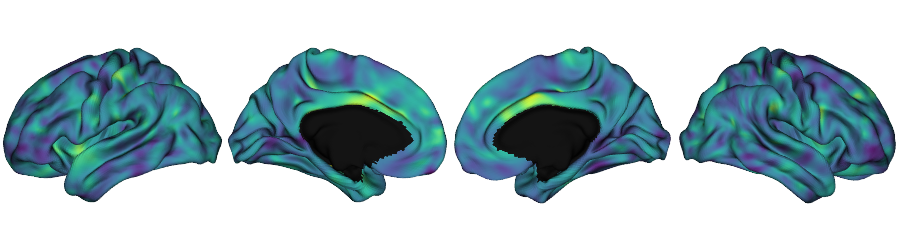

In [53]:
plot_hemispheres(f32k_lh, f32k_rh, y_pred, embed_nb=True, size=(900,250), zoom=1.25)

In [54]:
mask = midwall == 1

# Step 1: select features (first 200 eigenmodes)
X = eigenmodes[:, :n_modes]
X_masked = X[mask]
y_masked = par_PNC019[mask]

# Step 2: z-score normalization
X_masked = (X_masked - X_masked.mean(axis=0)) / X_masked.std(axis=0)

# Step 3: linear regression
model = LinearRegression()
model.fit(X_masked, y_masked)

# Step 4: prediction and performance evaluation
y_pred_masked = model.predict(X_masked)

# Reconstruct full vertex-wise prediction (fill non-cortical with NaN)
y_pred = np.zeros_like(par_PNC019)
y_pred[mask] = y_pred_masked
y_pred[~mask] = np.nan

# Compute evaluation metrics
r2 = r2_score(y_masked, y_pred_masked)
mse = mean_squared_error(y_masked, y_pred_masked)
corr, _ = pearsonr(y_masked, y_pred_masked)

print(f"R² = {r2:.3f}, MSE = {mse:.4f}, Pearson r = {corr:.3f}")

rho, pval = spearmanr(y_masked, y_pred_masked)
print(f"Spearman rho = {rho:.3f}, p = {pval:.3e}")

R² = 0.465, MSE = 0.0175, Pearson r = 0.682
Spearman rho = 0.673, p = 0.000e+00


In [55]:
y_pred = np.full_like(par_PNC019, fill_value=np.nan, dtype=float)
y_pred[mask] = y_pred_masked
y_pred.shape

(64984,)

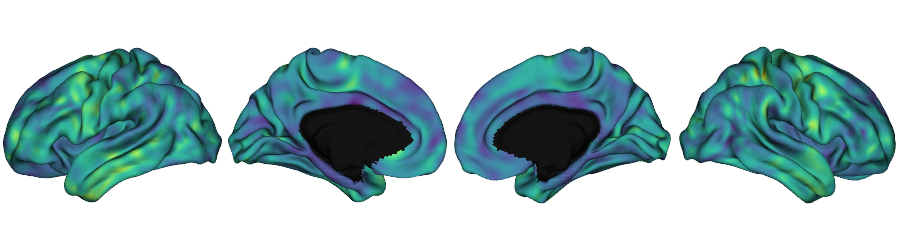

In [56]:
plot_hemispheres(f32k_lh, f32k_rh, y_pred, embed_nb=True, size=(900,250), zoom=1.25)